# Đánh giá & So sánh Mô hình

Sổ tay này đánh giá và so sánh ba mô hình đã được hoàn thiện:

- Hồi quy Logistic

- Rừng ngẫu nhiên

- XGBoost

Tất cả các mô hình đều được huấn luyện trước và tải từ các tệp tin được lưu trữ.

Không có quá trình huấn luyện lại nào được thực hiện trong sổ tay này.

In [1]:
import pickle
import joblib
import pandas as pd
import numpy as np

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

AttributeError: partially initialized module 'pandas' from 'C:\Users\PC\PycharmProjects\PythonProject\.venv\Lib\site-packages\pandas\__init__.py' has no attribute '_pandas_datetime_CAPI' (most likely due to a circular import)

Load test data (CHỈ TEST)

In [20]:
X_test = pd.read_csv(r"C:\Users\PC\PycharmProjects\PythonProject\ML\PROJECT\CHí BI=ình\data.csv")
y_test = pd.read_csv(r"C:\Users\PC\PycharmProjects\PythonProject\ML\PROJECT\CHí BI=ình\data.csv").squeeze()

Load models & thresholds

In [2]:
# Logistic Regression
lr_model = joblib.load(r"C:\Users\PC\PycharmProjects\PythonProject\ML\PROJECT\CHí BI=ình\logistic_regression_resampled.pkl")
lr_threshold = joblib.load(r"C:\Users\PC\PycharmProjects\PythonProject\ML\PROJECT\CHí BI=ình\best_threshold.pkl")

# Random Forest
rf_model = joblib.load(r"C:\Users\PC\PycharmProjects\PythonProject\ML\PROJECT\CHí BI=ình\random_forest_final.pkl")
rf_threshold = joblib.load(r"C:\Users\PC\PycharmProjects\PythonProject\ML\PROJECT\CHí BI=ình\rf_best_threshold.pkl")

# XGBoost
xgb_model = joblib.load(r"C:\Users\PC\PycharmProjects\PythonProject\ML\PROJECT\CHí BI=ình\xgboost_final.pkl")
xgb_threshold = joblib.load(r"C:\Users\PC\PycharmProjects\PythonProject\ML\PROJECT\CHí BI=ình\xgb_best_threshold.pkl")


AttributeError: partially initialized module 'pandas' from 'C:\Users\PC\PycharmProjects\PythonProject\.venv\Lib\site-packages\pandas\__init__.py' has no attribute '_pandas_datetime_CAPI' (most likely due to a circular import)

Helper function

In [6]:
def evaluate_model(name, model, X, y, threshold):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "model": name,
        "roc_auc": roc_auc_score(y, y_prob),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "threshold": threshold,
        "confusion_matrix": confusion_matrix(y, y_pred)
    }

Evaluate 3 models

In [8]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        lr_model,
        X_test,
        y_test,
        lr_threshold['best_threshold']
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        rf_model,
        X_test,
        y_test,
        rf_threshold['best_threshold']
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        xgb_model,
        X_test,
        y_test,
        xgb_threshold['best_threshold']
    )
)

results_df = pd.DataFrame(results).drop(columns="confusion_matrix")
results_df


,model,roc_auc,precision,recall,f1,threshold
0,Logistic Regression,0.966733,0.570726,0.564820,0.567758,0.839616
1,Random Forest,0.966421,0.768158,0.637249,0.696607,0.634812
2,XGBoost,0.971583,0.819785,0.650639,0.725484,0.825725


Confusion Matrix comparison

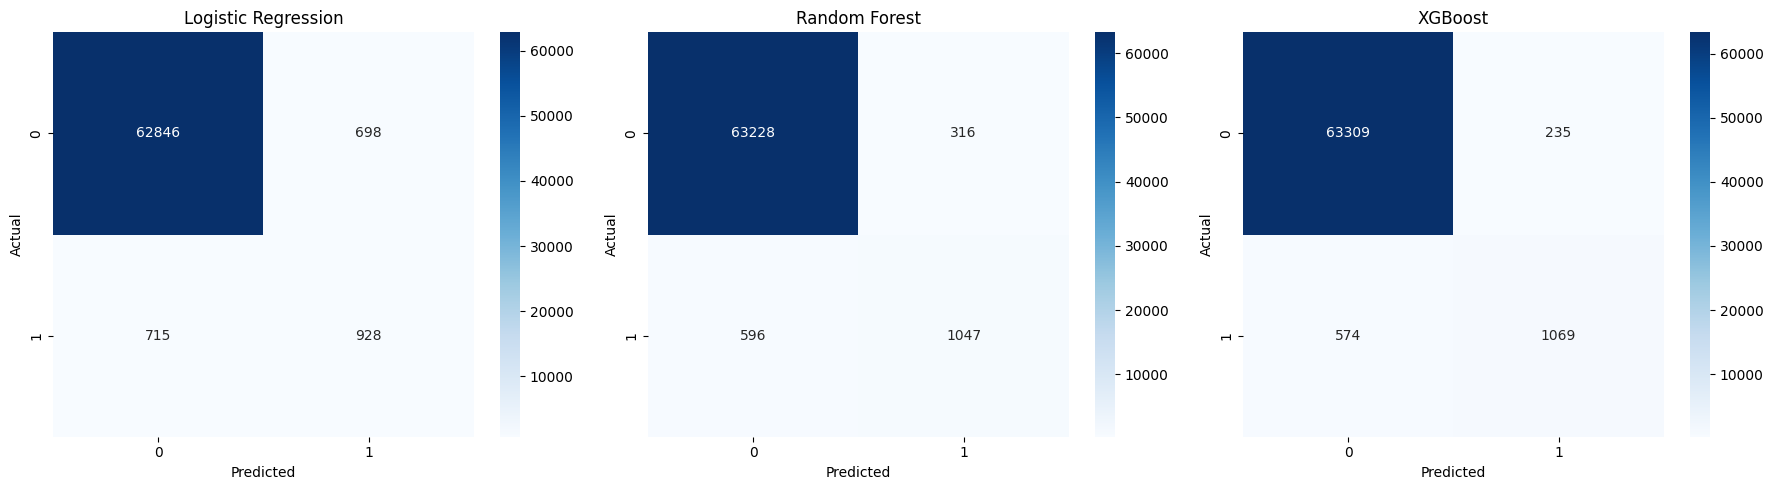

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, res in zip(axes, results):
    sns.heatmap(
        res["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )
    ax.set_title(res["model"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

ROC Curve comparison

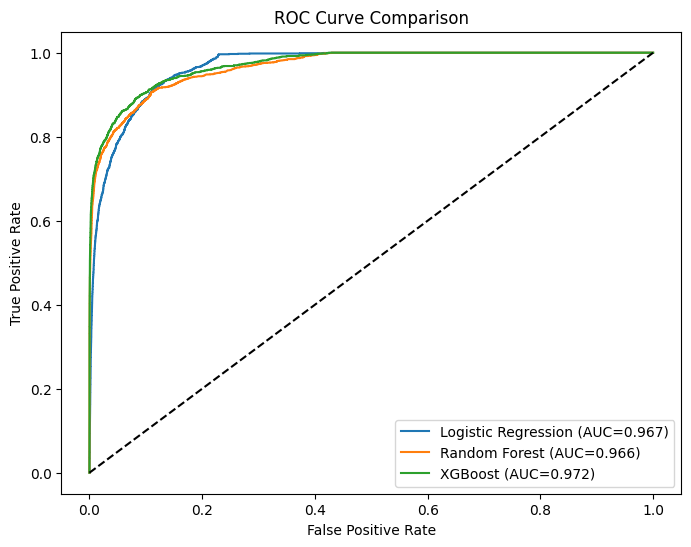

In [10]:
plt.figure(figsize=(8, 6))

for name, model in [
    ("Logistic Regression", lr_model),
    ("Random Forest", rf_model),
    ("XGBoost", xgb_model),
]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

Precision–Recall Curve

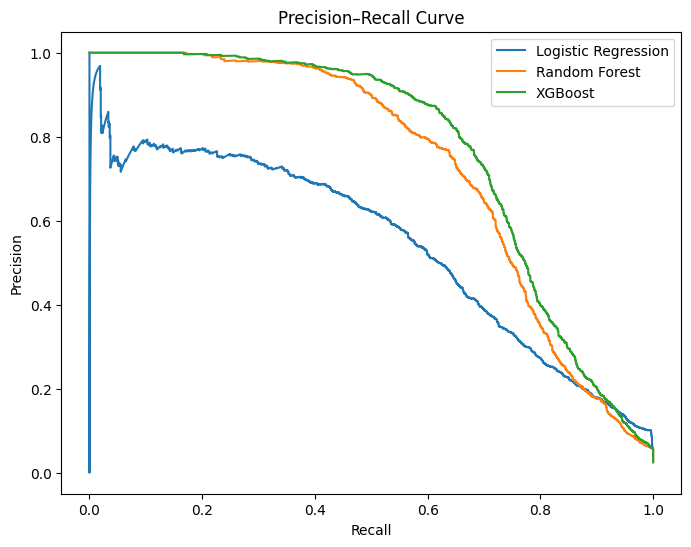

In [11]:
plt.figure(figsize=(8, 6))

for name, model in [
    ("Logistic Regression", lr_model),
    ("Random Forest", rf_model),
    ("XGBoost", xgb_model),
]:
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()


## Kết luận

- Hồi quy Logistic đạt được độ nhạy cao nhất nhưng độ chính xác thấp.

- Rừng ngẫu nhiên cung cấp hiệu suất cân bằng nhất và phù hợp với các hệ thống sản xuất ít rủi ro.

- XGBoost mang lại hiệu suất tổng thể cao nhất (ROC-AUC) và độ nhạy mạnh sau khi tối ưu hóa ngưỡng.

Việc lựa chọn mô hình phụ thuộc vào chi phí kinh doanh của sai sót dương tính giả so với sai sót âm tính giả.